**Introduction**

>Credit card fraud has become one of the most significant challenges faced by financial institutions as the volume of digital transactions continues to grow. Fraudulent transactions account for only a tiny fraction of all credit card activities, making fraud detection a highly imbalanced classification problem. Traditional rule-based systems often struggle to identify new and evolving fraud patterns, creating a need for machine learning techniques that can effectively distinguish between legitimate and fraudulent transactions while minimizing false alarms.

>Support Vector Machines (SVMs) are powerful supervised learning algorithms widely used for binary classification tasks due to their ability to find optimal decision boundaries between classes. Depending on the nature of the data, SVMs can employ different kernel functions. A Linear SVM is suitable when the classes can be separated using a linear decision boundary, whereas the Radial Basis Function (RBF) SVM uses a non-linear kernel to capture more complex relationships within the data. Comparing these two approaches provides valuable insights into the trade-offs between computational efficiency, model complexity, and predictive performance.

>In this project, the Credit Card Fraud Detection dataset is used to build and evaluate both Linear and RBF SVM classifiers.



In [ ]:
#Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [ ]:
#Loading Dataset

import pandas as pd

df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
#Explore Dataset

print(df.shape)

df.info()

df.describe()

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
#Handling Missing Values
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


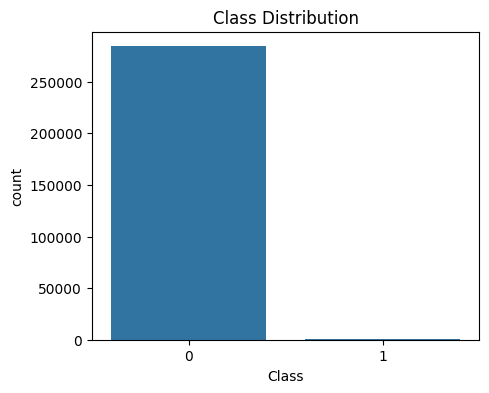

Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
#Plotting class distribution

plt.figure(figsize=(5,4))

sns.countplot(x='Class', data=df)

plt.title("Class Distribution")
plt.show()

print(df['Class'].value_counts())

**Dataset Changes**

In this project, the Credit Card Fraud Detection dataset is used to build and evaluate both Linear and RBF SVM classifiers. Since fraudulent transactions are significantly outnumbered by legitimate ones, the dataset is balanced through random undersampling before model training. The data is then preprocessed using feature scaling and split into training and testing sets. Both SVM models are trained using the same preprocessing pipeline to ensure a fair comparison.




In [ ]:
#Creating Balanced Dataset

# Separate Fraud and Normal Transactions

fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print("Fraud:", fraud.shape)
print("Normal:", normal.shape)

# Sample Normal Transactions (1:4 ratio)

normal_sample = normal.sample(
    n=len(fraud)*4,
    random_state=42
)

# Combine

balanced_df = pd.concat([fraud, normal_sample])

# Shuffle

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(balanced_df['Class'].value_counts())

Fraud: (492, 31)
Normal: (284315, 31)
Class
0    1968
1     492
Name: count, dtype: int64


>The original dataset contains 492 fraudulent transactions and 284,315 legitimate transactions, resulting in a highly imbalanced class distribution.

>The dataset contains 31 columns, comprising 30 input features (Time, Amount, and anonymized features V1–V28) and one target variable (Class) used to identify fraudulent transactions.

>To reduce this imbalance, a random undersampling technique was applied, where all 492 fraud cases were retained and 1,968 normal transactions (four times the number of fraud cases) were randomly sampled, creating a 1:4 fraud-to-normal ratio.

>The resulting balanced dataset contains 2,460 transactions (1,968 normal and 492 fraudulent), providing a more representative dataset for training the SVM models and improving their ability to learn patterns associated with fraudulent transactions.

In [ ]:
#Common Test and Train Split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = balanced_df.drop("Class", axis=1)
y = balanced_df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
#Option 1: RBF SVM on a Balanced Dataset

from sklearn.svm import SVC
import time

start = time.time()

rbf_svm = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=True,
    random_state=42
)

rbf_svm.fit(X_train, y_train)

rbf_train_time = time.time() - start

print("Training Time:", round(rbf_train_time,2),"seconds")

Training Time: 0.22 seconds


In [ ]:
#Saving Outputs from Option 1

y_pred_rbf = rbf_svm.predict(X_test)

y_prob_rbf = rbf_svm.predict_proba(X_test)[:,1]

y_test_bal = y_test.copy()

In [ ]:
#Option 2: Linear SVC on the Full Dataset

from sklearn.svm import LinearSVC

start = time.time()

linear_svm = LinearSVC(
    class_weight='balanced',
    C=10,
    max_iter=20000,
    random_state=42
)

linear_svm.fit(X_train, y_train)

linear_train_time = time.time()-start

print("Training Time:", round(linear_train_time,2),"seconds")


Training Time: 0.01 seconds


In [ ]:
# Save outputs of Linear SVC
y_pred_linear = linear_svm.predict(X_test)

scores_linear = linear_svm.decision_function(X_test)

y_test_full = y_test.copy()

In [ ]:
print("Predicted classes (Linear SVM):")
print(pd.Series(y_pred_linear).value_counts())

print("\nActual classes:")
print(pd.Series(y_test_full).value_counts())

print("Predicted classes (RBF SVM):")
print(pd.Series(y_pred_rbf).value_counts())

Predicted classes (Linear SVM):
0    394
1     98
Name: count, dtype: int64

Actual classes:
Class
0    394
1     98
Name: count, dtype: int64
Predicted classes (RBF SVM):
0    407
1     85
Name: count, dtype: int64


In [ ]:
print(balanced_df["Class"].value_counts())


Class
0    1968
1     492
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import classification_report

print("===== RBF SVM =====")
print(classification_report(y_test_bal, y_pred_rbf, zero_division=0))

print("\n===== Linear SVM =====")
print(classification_report(y_test_full, y_pred_linear, zero_division=0))

===== RBF SVM =====
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       394
           1       0.96      0.84      0.90        98

    accuracy                           0.96       492
   macro avg       0.96      0.91      0.94       492
weighted avg       0.96      0.96      0.96       492


===== Linear SVM =====
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       394
           1       0.90      0.90      0.90        98

    accuracy                           0.96       492
   macro avg       0.94      0.94      0.94       492
weighted avg       0.96      0.96      0.96       492



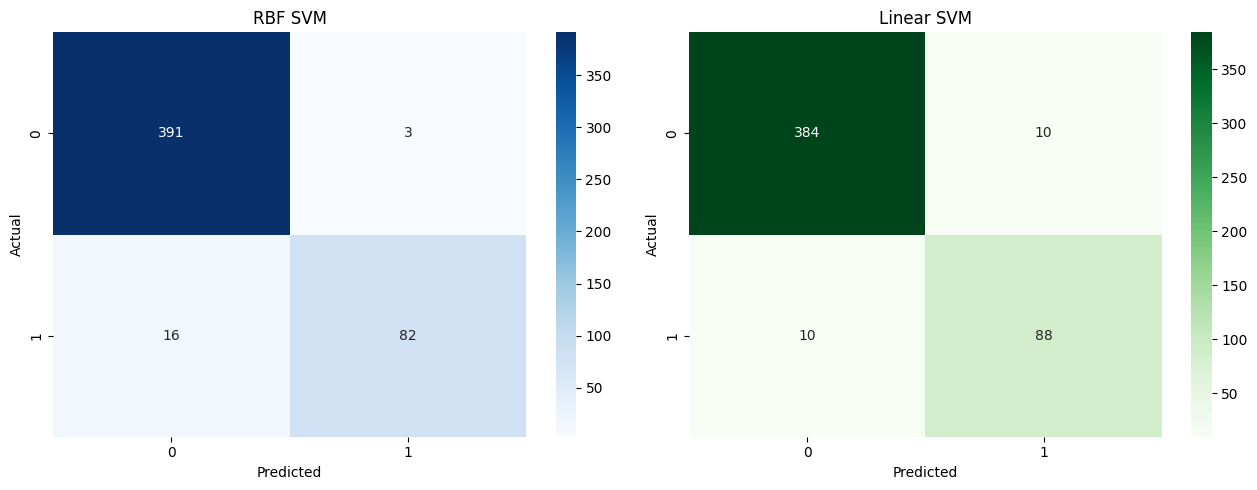

In [ ]:
#Side-by-Side Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_rbf = confusion_matrix(y_test_bal, y_pred_rbf)
cm_linear = confusion_matrix(y_test_full, y_pred_linear)

fig, ax = plt.subplots(1, 2, figsize=(13,5))

sns.heatmap(
    cm_rbf,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0]
)

ax[0].set_title("RBF SVM")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(
    cm_linear,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=ax[1]
)

ax[1].set_title("Linear SVM")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

>Insight: In credit card fraud detection, recall is often more important than precision because failing to detect a fraudulent transaction (false negative) can result in direct financial losses and security risks for both the customer and the credit card company. (Assuming that the fraud class is denoted by 1).

>Although the RBF SVM achieved higher precision by generating fewer false alarms, the Linear SVM achieved a higher recall (89.8%), identifying a greater proportion of fraudulent transactions. In real-world fraud detection systems, organizations generally prioritize models with higher recall, as investigating a few additional legitimate transactions is often less costly than allowing fraudulent transactions to go undetected.

>The confusion matrices show that both SVM models achieved strong classification performance on the balanced dataset. The RBF SVM correctly classified 391 legitimate transactions (True Negatives) and 82 fraudulent transactions (True Positives), while misclassifying 3 legitimate transactions as fraud (False Positives) and 16 fraudulent transactions as legitimate (False Negatives).

>In comparison, the Linear SVM correctly identified 384 legitimate transactions and 88 fraudulent transactions, with 10 false positives and 10 false negatives. These results indicate that the RBF SVM is more conservative, producing fewer false alarms but missing more fraud cases, whereas the Linear SVM detects more fraudulent transactions while generating a slightly higher number of false positives.



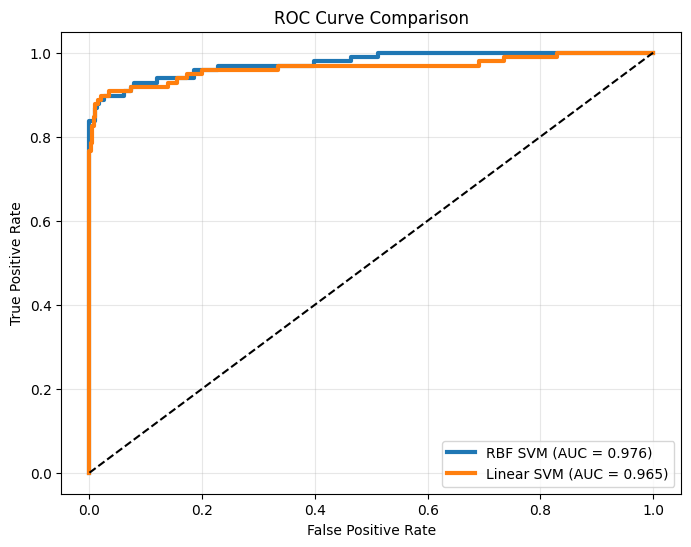

In [ ]:
#Side-by-Side ROC Curve

from sklearn.metrics import roc_curve, roc_auc_score

fpr_rbf, tpr_rbf, _ = roc_curve(y_test_bal, y_prob_rbf)

fpr_linear, tpr_linear, _ = roc_curve(y_test_full, scores_linear)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_rbf,
    tpr_rbf,
    linewidth=3,
    label=f"RBF SVM (AUC = {roc_auc_score(y_test_bal, y_prob_rbf):.3f})"
)

plt.plot(
    fpr_linear,
    tpr_linear,
    linewidth=3,
    label=f"Linear SVM (AUC = {roc_auc_score(y_test_full, scores_linear):.3f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

>ROC-AUC Analysis: The ROC curve demonstrates the ability of the model to distinguish between fraudulent and legitimate transactions across different classification thresholds.

>The RBF SVM achieved a higher ROC-AUC score of 0.9756 compared to 0.9645 for the Linear SVM, indicating superior class separability and a greater ability to rank fraudulent transactions ahead of legitimate ones. This suggests that the RBF kernel captures the underlying non-linear patterns in the data more effectively.

>However, despite the higher ROC-AUC, the Linear SVM achieved a higher recall, making it a more suitable choice when the primary objective is to maximize fraud detection and minimize missed fraudulent transactions.

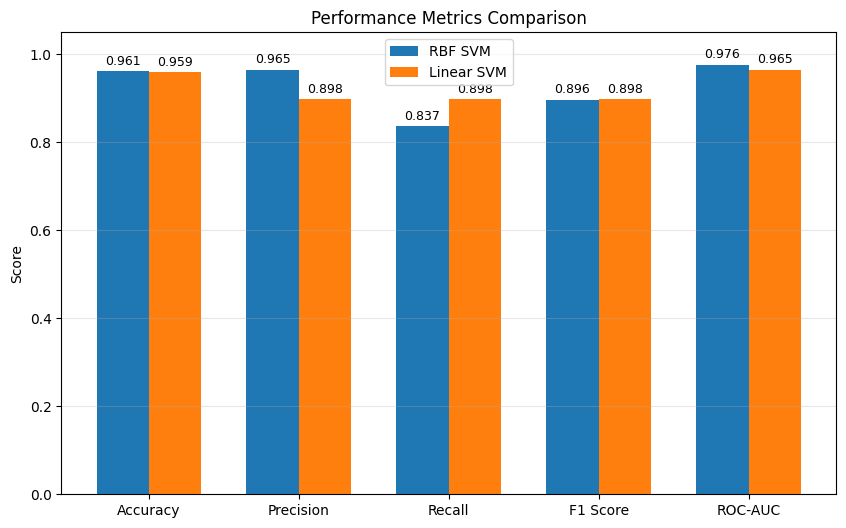

In [ ]:
#Performance Comparison Bar Chart

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = ["Accuracy","Precision","Recall","F1 Score","ROC-AUC"]

rbf_scores = [

    accuracy_score(y_test_bal,y_pred_rbf),

    precision_score(y_test_bal,y_pred_rbf),

    recall_score(y_test_bal,y_pred_rbf),

    f1_score(y_test_bal,y_pred_rbf),

    roc_auc_score(y_test_bal,y_prob_rbf)

]

linear_scores = [

    accuracy_score(y_test_full,y_pred_linear),

    precision_score(y_test_full,y_pred_linear),

    recall_score(y_test_full,y_pred_linear),

    f1_score(y_test_full,y_pred_linear),

    roc_auc_score(y_test_full,scores_linear)

]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x-width/2,
    rbf_scores,
    width,
    label="RBF SVM"
)

plt.bar(
    x+width/2,
    linear_scores,
    width,
    label="Linear SVM"
)

plt.xticks(x, metrics)

plt.ylim(0,1.05)

plt.ylabel("Score")

plt.title("Performance Metrics Comparison")

for i,v in enumerate(rbf_scores):
    plt.text(i-width/2,v+0.015,f"{v:.3f}",ha='center',fontsize=9)

for i,v in enumerate(linear_scores):
    plt.text(i+width/2,v+0.015,f"{v:.3f}",ha='center',fontsize=9)

plt.legend()

plt.grid(axis='y',alpha=0.3)

plt.show()

>Comparison of Linear and RBF SVM: The side-by-side comparison demonstrates that both SVM models achieved excellent performance in detecting fraudulent transactions. The RBF SVM recorded a slightly higher accuracy (96.14%), precision (96.47%), and ROC-AUC score (97.56%), indicating superior overall classification performance and better separation between fraudulent and legitimate transactions. In contrast, the Linear SVM achieved a higher recall (89.80%) and a marginally better F1-score (89.80%), demonstrating its ability to identify a larger proportion of fraudulent transactions while maintaining a good balance between precision and recall.

>Additionally, the Linear SVM required significantly less training time (0.013 s) compared to the RBF SVM (0.223 s), making it computationally more efficient. Overall, the RBF SVM provides better overall predictive performance, whereas the Linear SVM may be preferred in practical fraud detection scenarios where maximizing fraud detection (higher recall) and faster model training are of greater importance than minimizing false positives.

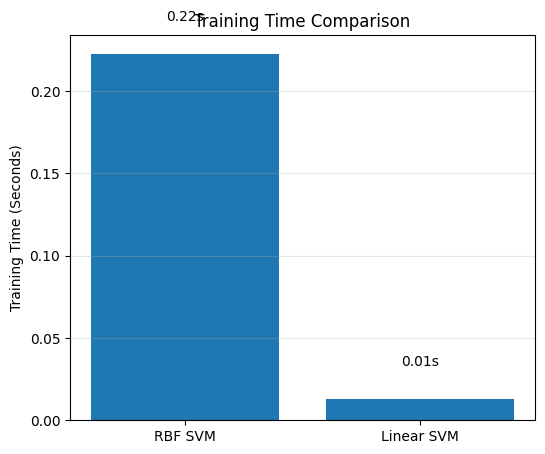

In [ ]:
#Training Time Comparison

plt.figure(figsize=(6,5))

plt.bar(
    ["RBF SVM","Linear SVM"],
    [rbf_train_time, linear_train_time]
)

for i,v in enumerate([rbf_train_time, linear_train_time]):
    plt.text(i,v+0.02,f"{v:.2f}s",ha='center')

plt.ylabel("Training Time (Seconds)")

plt.title("Training Time Comparison")

plt.grid(axis='y',alpha=0.3)

plt.show()

In [ ]:
#Final Performance Table

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Training Time (s)"
    ],

    "RBF SVM":[

        accuracy_score(y_test_bal,y_pred_rbf),

        precision_score(y_test_bal,y_pred_rbf),

        recall_score(y_test_bal,y_pred_rbf),

        f1_score(y_test_bal,y_pred_rbf),

        roc_auc_score(y_test_bal,y_prob_rbf),

        rbf_train_time

    ],

    "Linear SVM":[

        accuracy_score(y_test_full,y_pred_linear),

        precision_score(y_test_full,y_pred_linear),

        recall_score(y_test_full,y_pred_linear),

        f1_score(y_test_full,y_pred_linear),

        roc_auc_score(y_test_full,scores_linear),

        linear_train_time

    ]

})

comparison = comparison.round(4)

comparison

,Metric,RBF SVM,Linear SVM
0,Accuracy,0.9614,0.9593
1,Precision,0.9647,0.8980
2,Recall,0.8367,0.8980
3,F1 Score,0.8962,0.8980
4,ROC-AUC,0.9756,0.9645
5,Training Time (s),0.2228,0.0130


**Performance Analysis**

>The performance of the models is evaluated using metrics including accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, ROC curves, and training time. By comparing the strengths and limitations of Linear and RBF SVMs, this study aims to identify the most suitable classifier for credit card fraud detection while highlighting the practical trade-offs between maximizing fraud detection and minimizing false positive predictions.

>Credit card fraud detection is a challenging binary classification problem due to the highly imbalanced nature of transaction data. This project compares the performance of Linear and Radial Basis Function (RBF) Support Vector Machine (SVM) classifiers for identifying fraudulent transactions.

>After balancing the dataset and applying feature scaling, both models are trained and evaluated using metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices. The comparison highlights the effectiveness of linear and non-linear SVMs in detecting fraudulent credit card transactions.


*Results and Discussion**

> **Two Support Vector Machine (SVM) classifiers, namely the Radial Basis Function (RBF) SVM and Linear SVM, were trained and evaluated on a balanced subset of the Credit Card Fraud Detection dataset**.

> Both models achieved an overall accuracy of 96% and an F1-score of 0.90, demonstrating strong classification performance. The RBF SVM achieved a higher precision of 96%, indicating fewer false positive fraud detections, while the Linear SVM achieved a higher recall of 90%, successfully identifying a greater proportion of fraudulent transactions compared to the RBF SVM (84% recall).

> Both models exhibited comparable overall performance, as reflected by their identical F1-scores, with the trade-off lying between precision and recall. Since fraud detection applications generally prioritize minimizing missed fraudulent transactions, the Linear SVM provides a slight practical advantage by detecting more fraud cases, whereas the RBF SVM is better suited for scenarios where reducing false alarms is more critical.

>Overall, the results demonstrate that both linear and non-linear SVMs are effective classifiers for credit card fraud detection when trained on a balanced dataset, with the choice of model depending on the desired balance between fraud detection sensitivity and false positive rates.
